# Session 4 — OpenCV Basics (Part 2)
**Phase 1 · Foundations | Week 2 · Wednesday**

---

## What We'll Cover Today

| # | Topic | Key Concept |
|---|-------|-------------|
| 1 | Colour Conversion | BGR ↔ Gray, HSV, LAB |
| 2 | Thresholding | Global, Adaptive, Otsu's |
| 3 | Morphological Operations | Erosion, Dilation, Opening, Closing |
| 4 | Mini Exercise | Combining all three techniques |

---

> **Recap from Session 3:**  
> OpenCV stores images as **NumPy arrays** in **BGR** order.  
> Today we go deeper — learning how to **change colour representations**, **isolate regions by brightness**, and **clean up shapes** using morphological filters.

---
## 1. Setup & Imports

In [10]:
# ── Imports ───────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy  version : {np.__version__}")
print("All imports successful!")

OpenCV version : 4.10.0
NumPy  version : 2.2.6
All imports successful!


In [11]:
# ── Helper functions (same as Session 3) ─────────────────────────────────────

def show(img, title="Image", cmap=None):
    """Display a single OpenCV image (BGR or grayscale) inline."""
    plt.figure(figsize=(6, 5))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap="gray" if cmap is None else cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_multiple(images, titles, cols=3, figsize=(15, 4)):
    """Display multiple images side by side."""
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 3:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i].imshow(img, cmap="gray")
        axes[i].set_title(title, fontsize=10)
        axes[i].axis("off")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


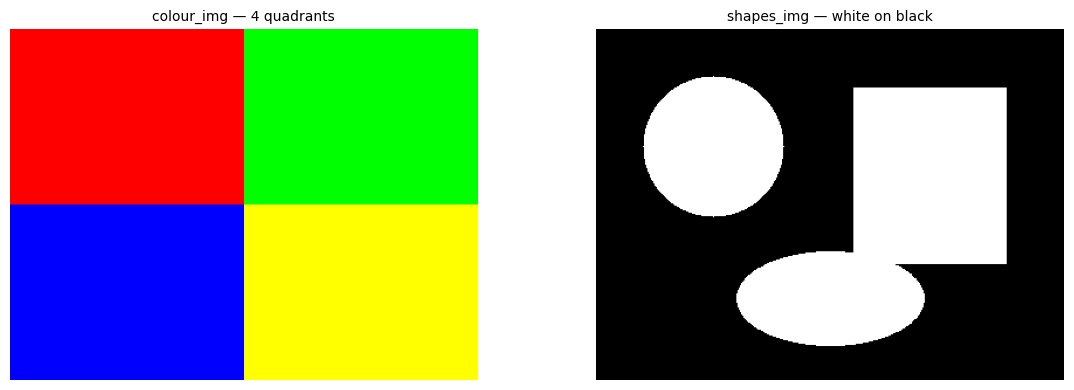

Test images ready.


In [12]:
# ── Create synthetic test images ──────────────────────────────────────────────
# We'll build two test images used throughout the session:
#   1. colour_img  — a colourful 4-quadrant image (same as Session 3)
#   2. shapes_img  — white shapes on a black background (perfect for thresholding)

h, w = 300, 400

# ── Image 1: four colour quadrants ───────────────────────────────────────────
colour_img = np.zeros((h, w, 3), dtype=np.uint8)
colour_img[0:h//2,  0:w//2]  = (0,   0,   255)   # Red    (BGR)
colour_img[0:h//2,  w//2:w]  = (0,   255,   0)   # Green
colour_img[h//2:h,  0:w//2]  = (255,   0,   0)   # Blue
colour_img[h//2:h,  w//2:w]  = (0,   255, 255)   # Yellow

# ── Image 2: white shapes on black canvas ─────────────────────────────────────
shapes_img = np.zeros((h, w, 3), dtype=np.uint8)
cv2.circle(shapes_img,    (100, 100), 60, (255, 255, 255), -1)   # filled circle
cv2.rectangle(shapes_img, (220, 50),  (350, 200), (255, 255, 255), -1)  # filled rect
cv2.ellipse(shapes_img,   (200, 230), (80, 40), 0, 0, 360, (255, 255, 255), -1)  # ellipse

# Save them so we can reload if needed
cv2.imwrite("colour_img.jpg",  colour_img)
cv2.imwrite("shapes_img.jpg",  shapes_img)

show_multiple(
    [colour_img, shapes_img],
    ["colour_img — 4 quadrants", "shapes_img — white on black"],
    cols=2, figsize=(12, 4)
)
print("Test images ready.")

---
## 2. Colour Conversion

### Why do we convert colour spaces?

Different colour spaces are **designed for different tasks**:

| Colour Space | What it separates | Common use |
|---|---|---|
| **BGR** | Blue, Green, Red channels | Default OpenCV format |
| **Grayscale** | Brightness only | Faster processing, edge detection |
| **HSV** | Hue (colour), Saturation, Value (brightness) | Colour-based object detection |
| **LAB** | Lightness, A (green↔red), B (blue↔yellow) | Perceptually uniform colour comparison |

The key function is `cv2.cvtColor(image, conversion_code)`.

---

### 2.1 BGR → Grayscale

Grayscale collapses three channels (R, G, B) into **one channel** representing brightness.  
OpenCV uses the formula:
```
Gray = 0.114 × B + 0.587 × G + 0.299 × R
```
Green contributes the most because the human eye is most sensitive to it.

Original shape : (300, 400, 3)   (height, width, channels)
Grayscale shape: (300, 400)          (height, width) — single channel


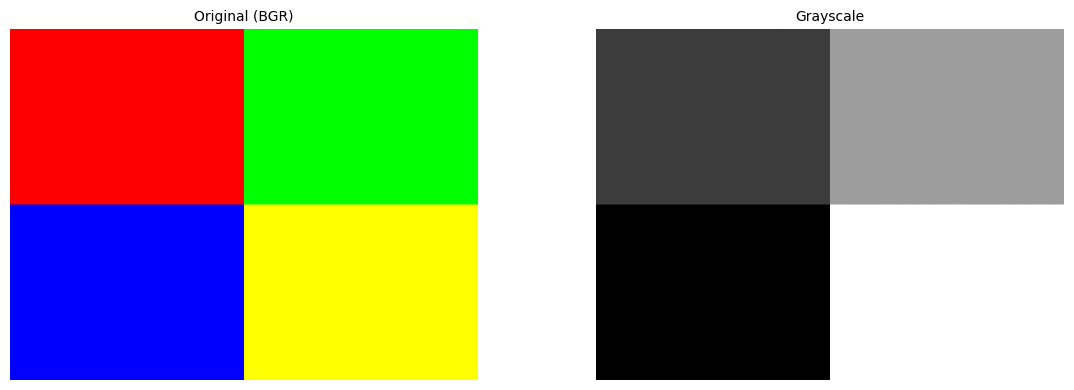

In [13]:
# ── BGR → Grayscale ───────────────────────────────────────────────────────────
gray = cv2.cvtColor(colour_img, cv2.COLOR_BGR2GRAY)

print(f"Original shape : {colour_img.shape}   (height, width, channels)")
print(f"Grayscale shape: {gray.shape}          (height, width) — single channel")

show_multiple(
    [colour_img, gray],
    ["Original (BGR)", "Grayscale"],
    cols=2, figsize=(12, 4)
)

Notice how **red and green** become **different shades of grey** even though they look equally bright to the eye — this is because the luminance formula weights them differently.

---

### 2.2 BGR → HSV

**HSV** is extremely useful for **detecting objects by colour**.

- **H (Hue)**: The *type* of colour — red, green, blue, etc. Range: 0–179 in OpenCV
- **S (Saturation)**: How *vivid* the colour is. 0 = grey, 255 = full colour
- **V (Value)**: How *bright* it is. 0 = black, 255 = brightest

The big advantage: **lighting changes** mostly affect V, leaving H and S stable — making colour detection robust.

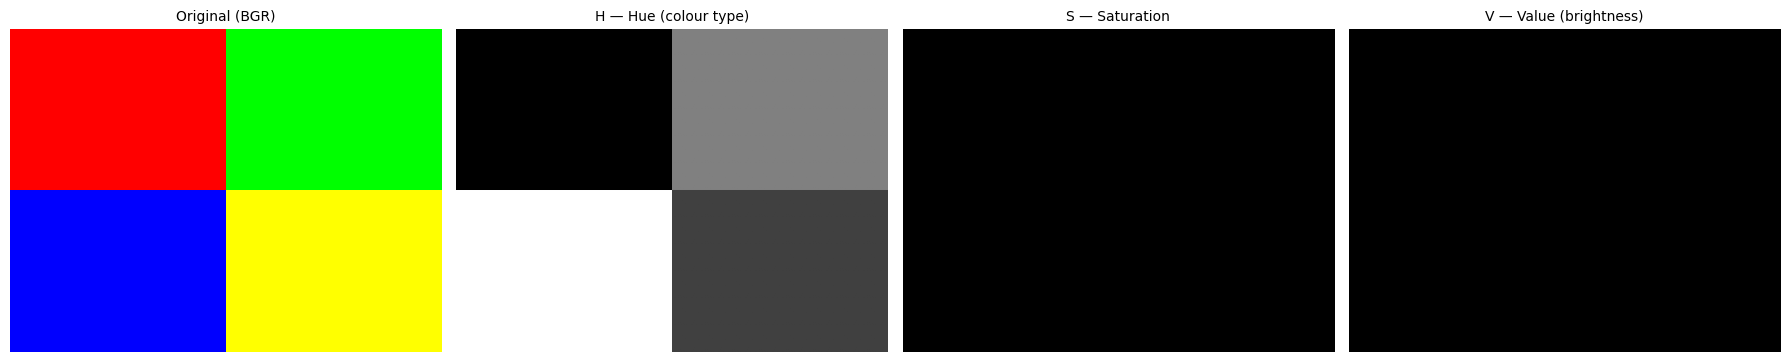

HSV ranges in OpenCV:
  H: 0–179  (red ≈ 0 or 179, green ≈ 60, blue ≈ 120)
  S: 0–255  (0 = grey/no colour, 255 = vivid colour)
  V: 0–255  (0 = black, 255 = brightest)


In [14]:
# ── BGR → HSV ─────────────────────────────────────────────────────────────────
hsv = cv2.cvtColor(colour_img, cv2.COLOR_BGR2HSV)

# Split into individual channels
h_ch, s_ch, v_ch = cv2.split(hsv)

# Display each channel as a grayscale image
show_multiple(
    [colour_img, h_ch, s_ch, v_ch],
    ["Original (BGR)", "H — Hue (colour type)", "S — Saturation", "V — Value (brightness)"],
    cols=4, figsize=(18, 4)
)

print("HSV ranges in OpenCV:")
print(f"  H: 0–179  (red ≈ 0 or 179, green ≈ 60, blue ≈ 120)")
print(f"  S: 0–255  (0 = grey/no colour, 255 = vivid colour)")
print(f"  V: 0–255  (0 = black, 255 = brightest)")

---

### 2.3 Practical: Isolating a Colour with HSV Masking

One of the most common uses of HSV: **create a mask that keeps only one colour**.  
We use `cv2.inRange(hsv, lower_bound, upper_bound)` — it returns a **binary mask** (white where the condition is met, black elsewhere).

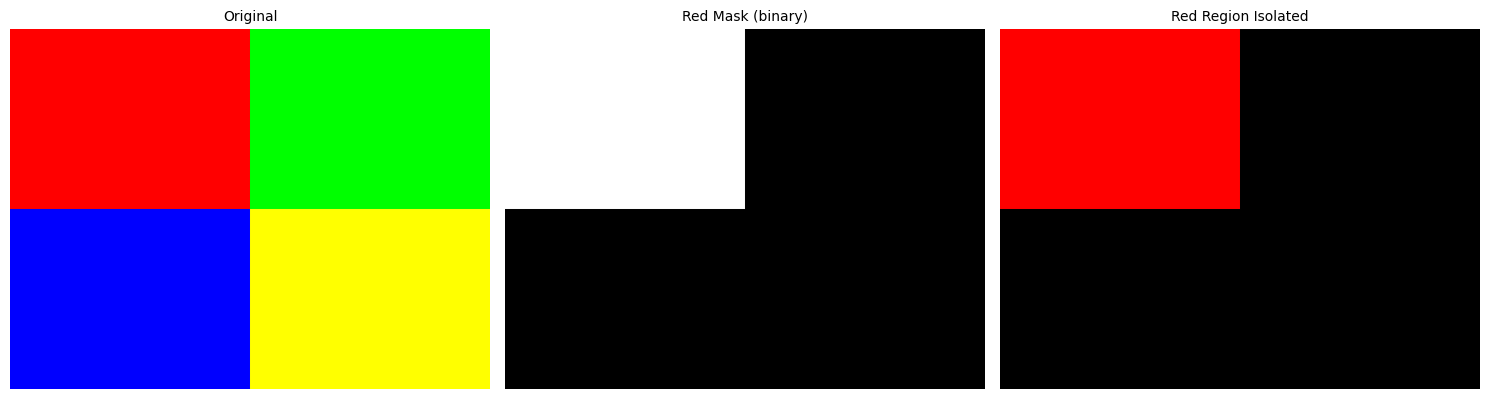

In [15]:
# ── Isolate the RED region using HSV masking ──────────────────────────────────
# Red in HSV wraps around — it appears near H=0 AND H=179
# We create two ranges and combine them with cv2.bitwise_or

hsv = cv2.cvtColor(colour_img, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0,   120, 70])
upper_red1 = np.array([10,  255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)

# Apply the mask — keep only the red pixels from the original image
result = cv2.bitwise_and(colour_img, colour_img, mask=red_mask)

show_multiple(
    [colour_img, red_mask, result],
    ["Original", "Red Mask (binary)", "Red Region Isolated"],
    cols=3, figsize=(15, 4)
)

---

### 2.4 BGR → LAB

**LAB** is designed to be **perceptually uniform** — meaning equal distances in LAB correspond to equal perceived colour differences by humans.

- **L**: Lightness (0 = black, 100 = white)
- **A**: Green (−) ↔ Red (+)
- **B**: Blue (−) ↔ Yellow (+)

LAB is useful for **comparing colours across different lighting conditions** and for subtle colour adjustments.

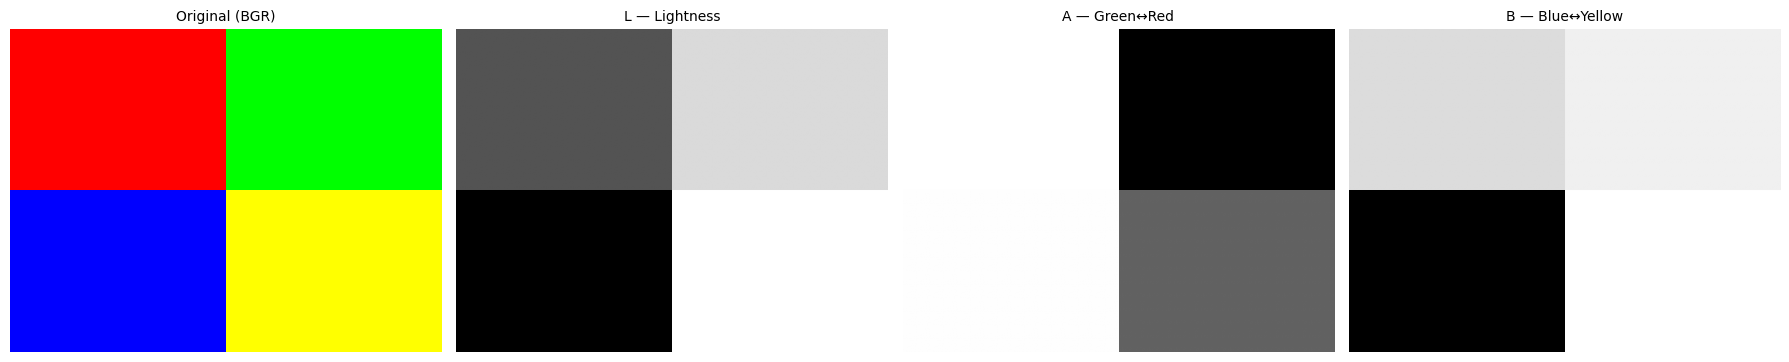

In OpenCV's LAB encoding (8-bit):
  L: 0–255  (mapped from 0–100)
  A: 0–255  (128 = neutral, <128 = green, >128 = red)
  B: 0–255  (128 = neutral, <128 = blue, >128 = yellow)


In [16]:
# ── BGR → LAB ─────────────────────────────────────────────────────────────────
lab = cv2.cvtColor(colour_img, cv2.COLOR_BGR2LAB)

l_ch, a_ch, b_ch = cv2.split(lab)

show_multiple(
    [colour_img, l_ch, a_ch, b_ch],
    ["Original (BGR)", "L — Lightness", "A — Green↔Red", "B — Blue↔Yellow"],
    cols=4, figsize=(18, 4)
)

print("In OpenCV's LAB encoding (8-bit):")
print("  L: 0–255  (mapped from 0–100)")
print("  A: 0–255  (128 = neutral, <128 = green, >128 = red)")
print("  B: 0–255  (128 = neutral, <128 = blue, >128 = yellow)")

---

### 2.5 Quick Summary: Conversion Codes

Here's a handy reference for the conversions we've covered and others you'll encounter:

In [17]:
# ── Common cvtColor codes ─────────────────────────────────────────────────────
conversions = {
    "BGR → Grayscale" : cv2.COLOR_BGR2GRAY,
    "BGR → HSV"       : cv2.COLOR_BGR2HSV,
    "BGR → LAB"       : cv2.COLOR_BGR2LAB,
    "BGR → RGB"       : cv2.COLOR_BGR2RGB,
    "HSV → BGR"       : cv2.COLOR_HSV2BGR,
    "LAB → BGR"       : cv2.COLOR_LAB2BGR,
    "Gray → BGR"      : cv2.COLOR_GRAY2BGR,
}

print(f"{'Conversion':<22} | Code")
print("-" * 40)
for name, code in conversions.items():
    print(f"{name:<22} | {code}")

Conversion             | Code
----------------------------------------
BGR → Grayscale        | 6
BGR → HSV              | 40
BGR → LAB              | 44
BGR → RGB              | 4
HSV → BGR              | 54
LAB → BGR              | 56
Gray → BGR             | 8


---
## 3. Thresholding

### What is thresholding?

Thresholding converts a **grayscale image into a binary image** (black & white).  
Every pixel is compared to a threshold value **T**:

```
pixel > T  →  255  (white)  
pixel ≤ T  →    0  (black)
```

This is one of the **most fundamental segmentation techniques** in CV — separating objects from the background.

---

### 3.1 Simple (Global) Thresholding

A **single threshold value** is applied to the whole image.  
Simple and fast — but sensitive to lighting changes across the image.

In [18]:
img = cv2.imread("dog.jpg")

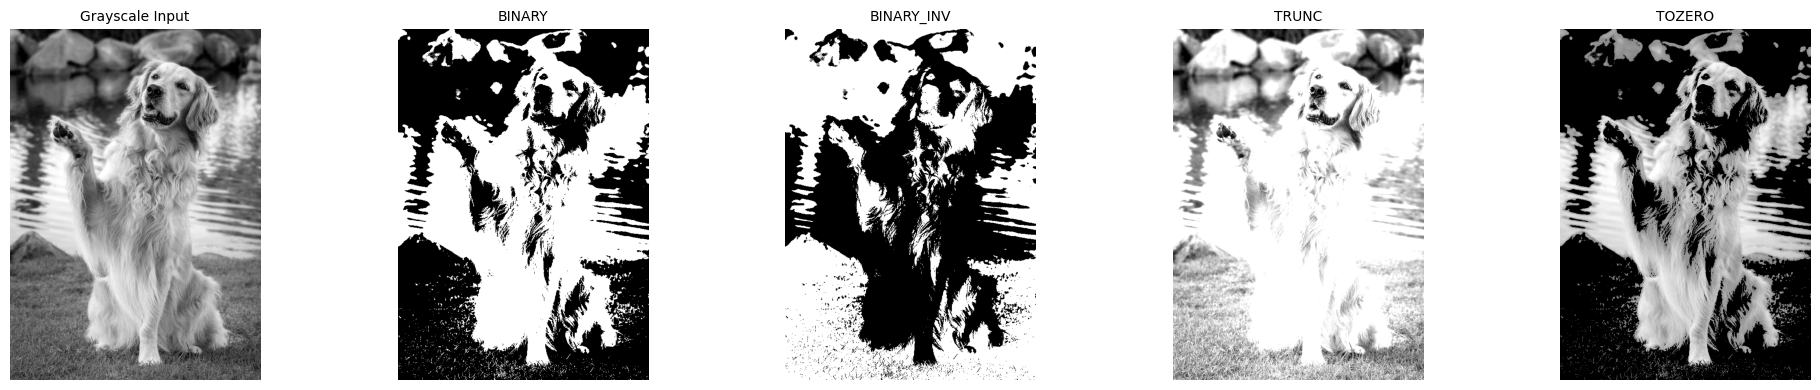

Threshold types explained:
  BINARY     : pixel > T → 255, else 0
  BINARY_INV : pixel > T → 0,   else 255  (inverted)
  TRUNC      : pixel > T → T,   else unchanged  (clips bright areas)
  TOZERO     : pixel > T → unchanged, else 0    (zeros out dark areas)


In [19]:
# ── Grayscale of the shapes image ─────────────────────────────────────────────
shapes_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ── Simple thresholding ───────────────────────────────────────────────────────
# cv2.threshold returns (threshold_used, thresholded_image)
# Syntax: cv2.threshold(src, thresh, maxval, type)

_, thresh_binary     = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_BINARY)
_, thresh_binary_inv = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_BINARY_INV)
_, thresh_trunc      = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_TRUNC)
_, thresh_tozero     = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_TOZERO)

show_multiple(
    [shapes_gray, thresh_binary, thresh_binary_inv, thresh_trunc, thresh_tozero],
    ["Grayscale Input", "BINARY", "BINARY_INV", "TRUNC", "TOZERO"],
    cols=5, figsize=(20, 4)
)

print("Threshold types explained:")
print("  BINARY     : pixel > T → 255, else 0")
print("  BINARY_INV : pixel > T → 0,   else 255  (inverted)")
print("  TRUNC      : pixel > T → T,   else unchanged  (clips bright areas)")
print("  TOZERO     : pixel > T → unchanged, else 0    (zeros out dark areas)")

---

### 3.2 Otsu's Thresholding — Automatic Threshold Selection

Picking the right threshold manually is tedious.  
**Otsu's method** automatically finds the **optimal threshold** by analysing the image's histogram — it finds the value that best separates the two peaks (foreground and background).

Just add `+ cv2.THRESH_OTSU` to the flags — and set `thresh=0` (it's ignored).

Otsu's automatically chose threshold = 136.0


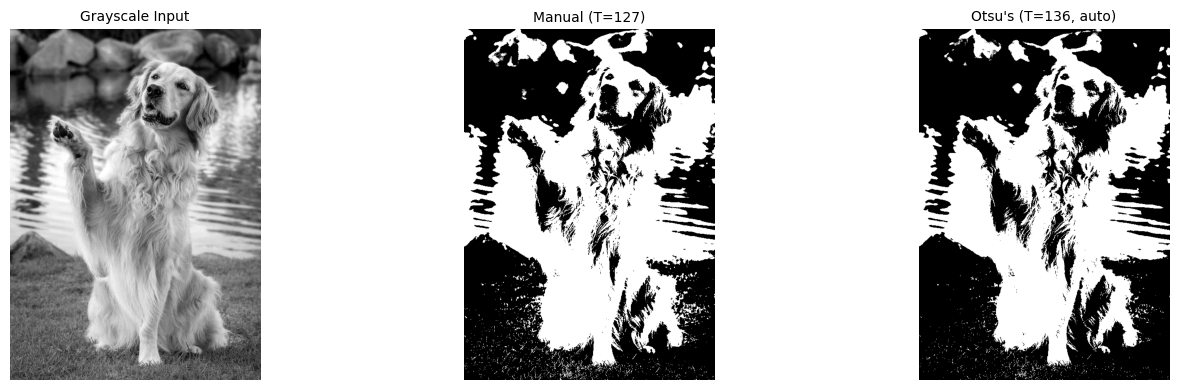

In [20]:
# ── Otsu's thresholding ───────────────────────────────────────────────────────
# Pass thresh=0; OpenCV computes it automatically using Otsu's algorithm.

otsu_thresh_val, thresh_otsu = cv2.threshold(
    shapes_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Otsu's automatically chose threshold = {otsu_thresh_val}")

# Compare: manual threshold vs. Otsu's
_, thresh_manual = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_BINARY)

show_multiple(
    [shapes_gray, thresh_manual, thresh_otsu],
    ["Grayscale Input", f"Manual (T=127)", f"Otsu's (T={otsu_thresh_val:.0f}, auto)"],
    cols=3, figsize=(15, 4)
)

---

### 3.3 Adaptive Thresholding — Handling Uneven Lighting

Global thresholding fails when **lighting varies across an image** — one region might be brighter, another darker, and a single T won't work for both.

**Adaptive thresholding** computes a **different threshold for each small neighbourhood** of pixels — adapting locally.

Two methods for computing the local threshold:
- `ADAPTIVE_THRESH_MEAN_C` — mean of neighbourhood pixels minus constant C
- `ADAPTIVE_THRESH_GAUSSIAN_C` — Gaussian-weighted average minus C (smoother)

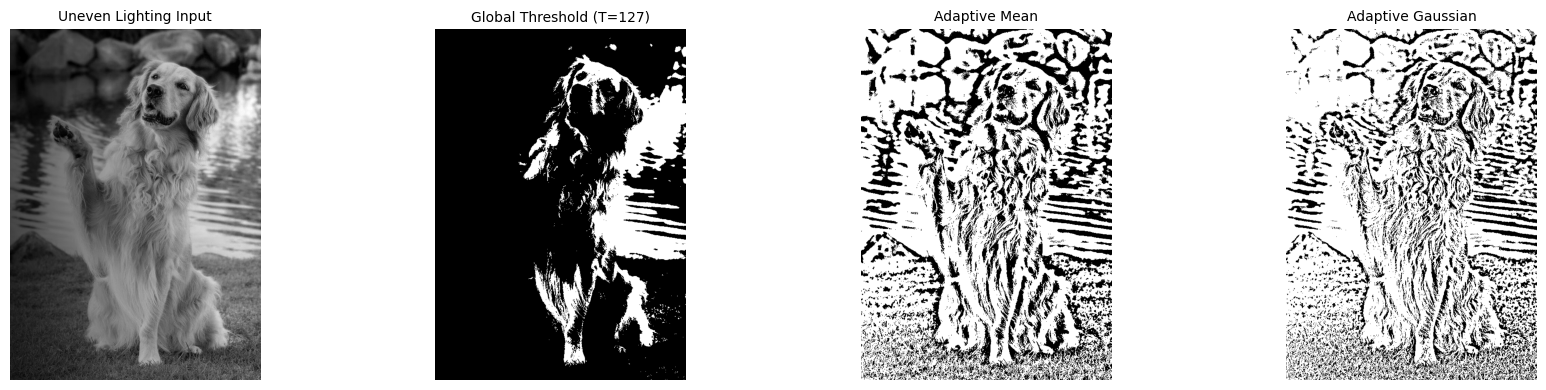

Notice: global threshold loses the shapes on the dark side.
Adaptive methods recover them by using local neighbourhoods.


In [22]:
# ── Simulate uneven lighting ──────────────────────────────────────────────────
# We'll create a gradient overlay on the shapes image to mimic shadows.

h, w = shapes_gray.shape[:2]                                     # Get actual dimensions of shapes_gray
gradient = np.linspace(0.3, 1.0, w, dtype=np.float32)           # left=darker, right=brighter
gradient = np.tile(gradient, (h, 1))                             # repeat for every row
uneven = (shapes_gray.astype(np.float32) * gradient).astype(np.uint8)

# ── Global threshold on the uneven image ─────────────────────────────────────
_, global_thresh = cv2.threshold(uneven, 127, 255, cv2.THRESH_BINARY)

# ── Adaptive threshold on the uneven image ───────────────────────────────────
# blockSize: size of local neighbourhood (must be odd)
# C: constant subtracted from the mean (fine-tune sensitivity)
adaptive_mean = cv2.adaptiveThreshold(
    uneven, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize=31, C=5
)

adaptive_gauss = cv2.adaptiveThreshold(
    uneven, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=31, C=5
)

show_multiple(
    [uneven, global_thresh, adaptive_mean, adaptive_gauss],
    ["Uneven Lighting Input", "Global Threshold (T=127)",
     "Adaptive Mean", "Adaptive Gaussian"],
    cols=4, figsize=(18, 4)
)

print("Notice: global threshold loses the shapes on the dark side.")
print("Adaptive methods recover them by using local neighbourhoods.")

---

### 3.4 Thresholding: Quick Comparison

| Method | How it works | Best for |
|---|---|---|
| **Simple / Binary** | One fixed T for whole image | Uniform lighting |
| **Otsu's** | Auto-picks T from histogram | Clean 2-tone images |
| **Adaptive Mean** | Local mean − C per neighbourhood | Uneven lighting |
| **Adaptive Gaussian** | Gaussian-weighted local mean − C | Uneven + noisy images |

---
## 4. Morphological Operations

### What are morphological operations?

Morphological operations work on **binary (or grayscale) images** and **change the shape of objects** by applying a small template called a **kernel** (or structuring element) over each pixel.

Think of them as **shape-aware filters** — used to:
- Remove noise (tiny white dots in a binary image)
- Fill gaps or holes in shapes
- Separate or connect objects

The two **fundamental** operations are **Erosion** and **Dilation** — all others are built from these two.

---

### 4.1 The Kernel (Structuring Element)

The **kernel** defines the "neighbourhood" OpenCV looks at.  
A pixel is affected based on its neighbours within the kernel's shape.

In [23]:
# ── Create structuring elements (kernels) ─────────────────────────────────────
# cv2.getStructuringElement(shape, (ksize, ksize))
# Shape options: MORPH_RECT, MORPH_ELLIPSE, MORPH_CROSS

kernel_rect    = cv2.getStructuringElement(cv2.MORPH_RECT,    (5, 5))
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_cross   = cv2.getStructuringElement(cv2.MORPH_CROSS,   (5, 5))

print("MORPH_RECT (5×5):")
print(kernel_rect)
print()
print("MORPH_ELLIPSE (5×5):")
print(kernel_ellipse)
print()
print("MORPH_CROSS (5×5):")
print(kernel_cross)

# We'll use a rectangular kernel for all examples below
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

MORPH_RECT (5×5):
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

MORPH_ELLIPSE (5×5):
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]

MORPH_CROSS (5×5):
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]


---

### 4.2 Erosion — Shrinking Objects

**Erosion** slides the kernel over the image. A pixel is kept as **white only if ALL pixels under the kernel are white**.  
Effect: **shrinks white regions**, removes small white noise, separates touching objects.

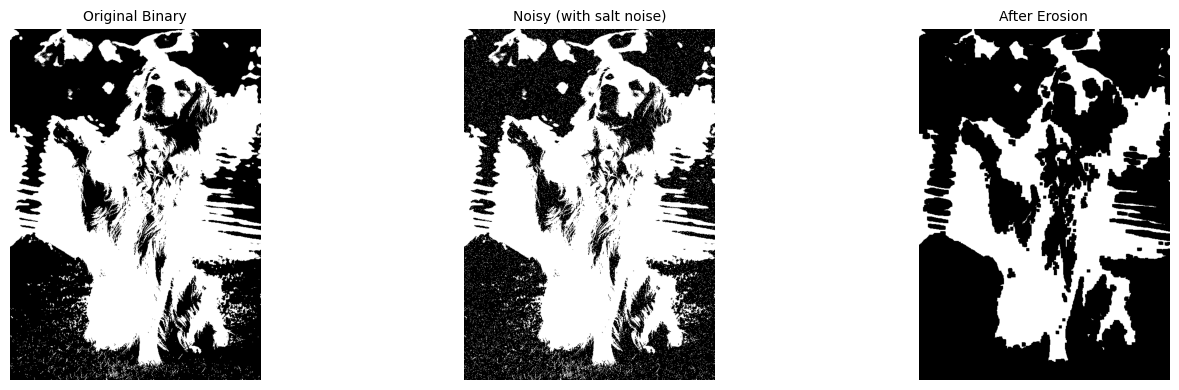

Erosion effect: shapes shrink, small noise dots disappear.


In [24]:
# ── Prepare a clean binary image ──────────────────────────────────────────────
_, binary = cv2.threshold(shapes_gray, 127, 255, cv2.THRESH_BINARY)

# ── Add salt noise (random white dots) to make erosion purpose clearer ────────
noisy = binary.copy()
noise_mask = np.random.randint(0, 100, noisy.shape) > 95   # ~5% of pixels become white
noisy[noise_mask] = 255

# ── Erosion ───────────────────────────────────────────────────────────────────
eroded = cv2.erode(noisy, kernel, iterations=1)

show_multiple(
    [binary, noisy, eroded],
    ["Original Binary", "Noisy (with salt noise)", "After Erosion"],
    cols=3, figsize=(15, 4)
)

print("Erosion effect: shapes shrink, small noise dots disappear.")

---

### 4.3 Dilation — Growing Objects

**Dilation** is the opposite of erosion. A pixel becomes white if **at least ONE pixel under the kernel is white**.  
Effect: **expands white regions**, fills small holes, connects nearby objects.

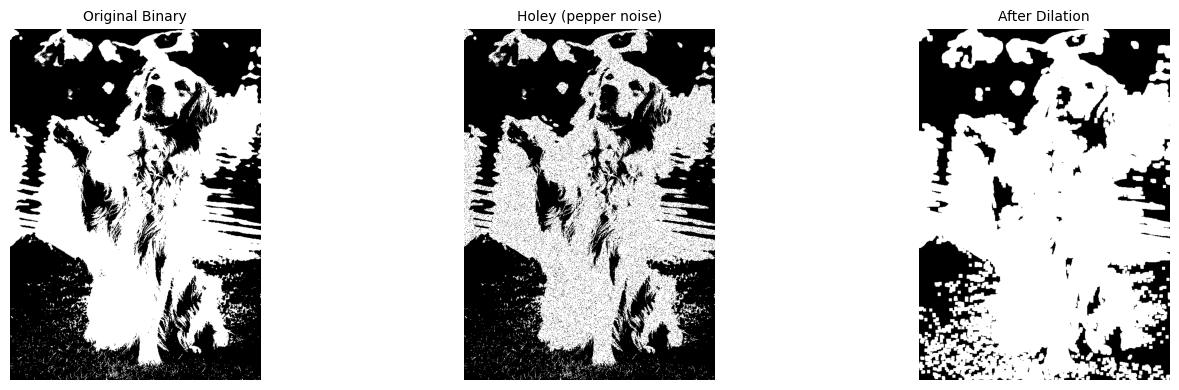

Dilation effect: shapes grow, small holes are filled, gaps are bridged.


In [25]:
# ── Pepper noise (random black holes inside shapes) ───────────────────────────
holey = binary.copy()
inner_noise = np.random.randint(0, 100, holey.shape) > 90   # ~10% become black holes
holey[inner_noise] = 0

# ── Dilation ──────────────────────────────────────────────────────────────────
dilated = cv2.dilate(holey, kernel, iterations=1)

show_multiple(
    [binary, holey, dilated],
    ["Original Binary", "Holey (pepper noise)", "After Dilation"],
    cols=3, figsize=(15, 4)
)

print("Dilation effect: shapes grow, small holes are filled, gaps are bridged.")

---

### 4.4 Opening — Erosion followed by Dilation

**Opening = Erosion → Dilation**

The erosion removes noise, then dilation restores the original shape size.  
Net effect: **removes small white objects (noise)** while largely preserving the main shapes.

Use it when you have **small noise dots around or inside objects**.

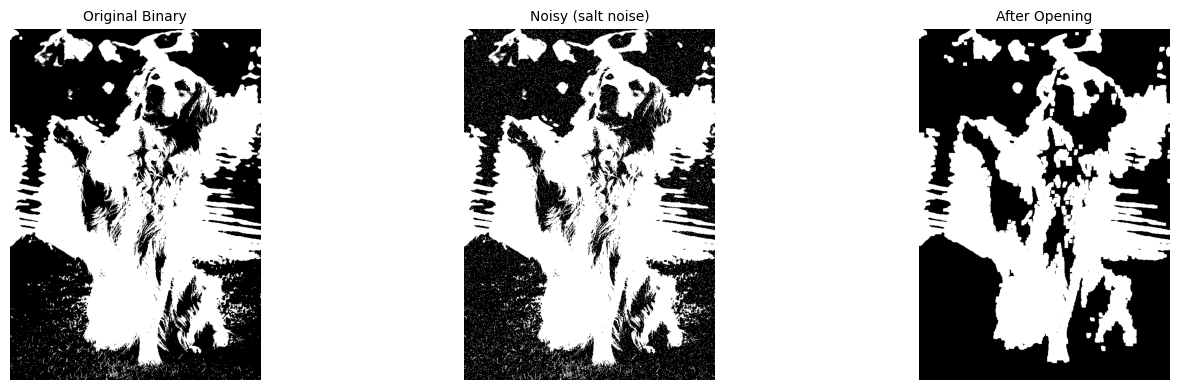

Opening: noise removed, shapes roughly restored to original size.


In [26]:
# ── Opening ───────────────────────────────────────────────────────────────────
# cv2.morphologyEx is the one-stop function for compound morphological ops.
opened = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)

show_multiple(
    [binary, noisy, opened],
    ["Original Binary", "Noisy (salt noise)", "After Opening"],
    cols=3, figsize=(15, 4)
)

print("Opening: noise removed, shapes roughly restored to original size.")

---

### 4.5 Closing — Dilation followed by Erosion

**Closing = Dilation → Erosion**

The dilation fills holes, then erosion shrinks back to the original size.  
Net effect: **fills small black holes or gaps inside objects** without changing their overall size.

Use it when you have **small holes or breaks inside a shape**.

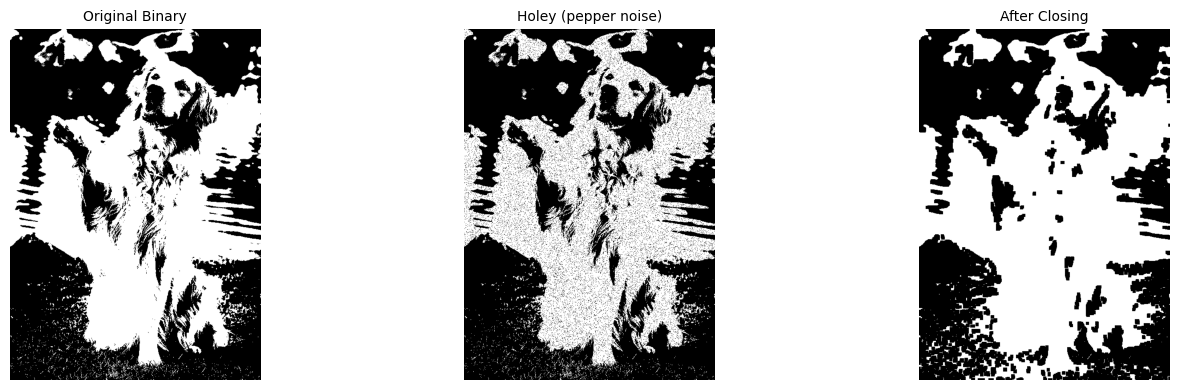

Closing: holes filled, shapes restored to approximately original size.


In [27]:
# ── Closing ───────────────────────────────────────────────────────────────────
closed = cv2.morphologyEx(holey, cv2.MORPH_CLOSE, kernel)

show_multiple(
    [binary, holey, closed],
    ["Original Binary", "Holey (pepper noise)", "After Closing"],
    cols=3, figsize=(15, 4)
)

print("Closing: holes filled, shapes restored to approximately original size.")

---

### 4.6 Morphological Gradient — Finding Edges

**Gradient = Dilation − Erosion**

The difference between the dilated and eroded image gives you the **outline (edge)** of each shape.

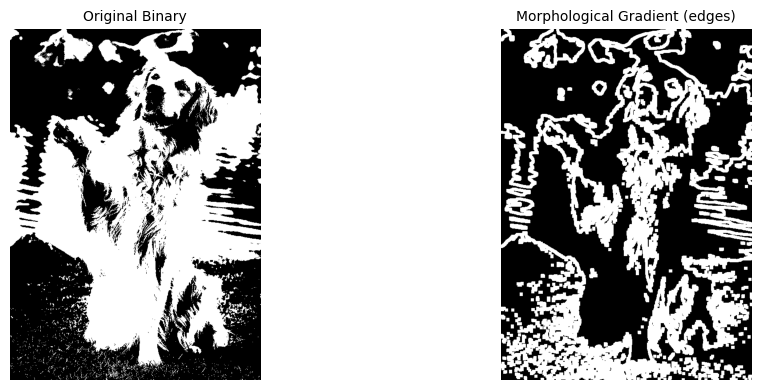

Gradient highlights the boundary/outline of each shape.


In [28]:
# ── Morphological Gradient ────────────────────────────────────────────────────
gradient_img = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

show_multiple(
    [binary, gradient_img],
    ["Original Binary", "Morphological Gradient (edges)"],
    cols=2, figsize=(12, 4)
)

print("Gradient highlights the boundary/outline of each shape.")

---

### 4.7 Summary — All Morphological Operations at Once

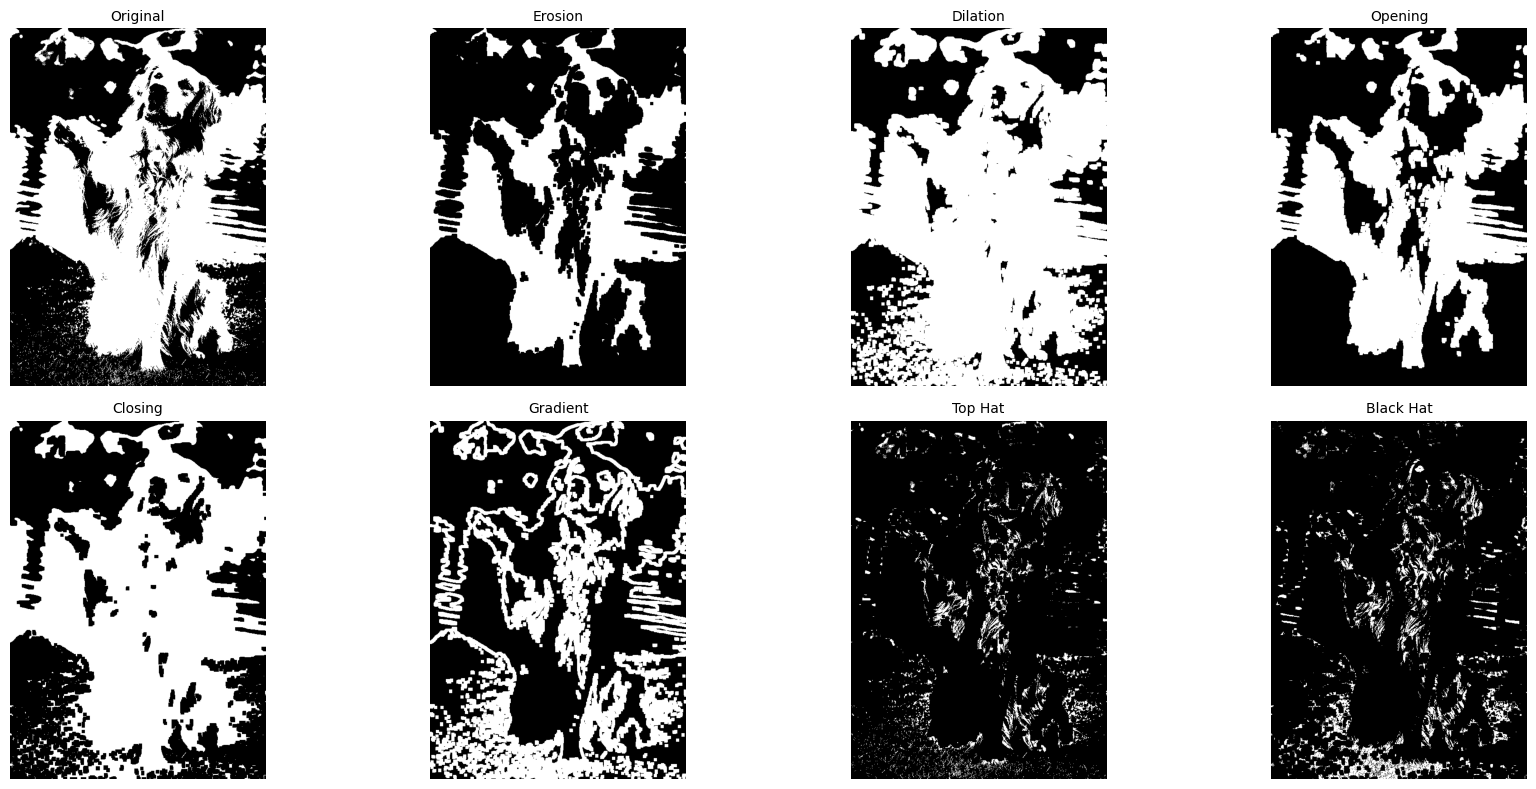


Summary:
  Erosion    — shrinks shapes, removes small white noise
  Dilation   — grows shapes, fills small black holes
  Opening    — removes small objects (erosion then dilation)
  Closing    — fills small holes (dilation then erosion)
  Gradient   — detects edges/outlines (dilation - erosion)
  Top Hat    — bright features smaller than kernel (original - opened)
  Black Hat  — dark holes/gaps smaller than kernel (closed - original)



In [29]:
# ── Side-by-side comparison of all morphological ops ─────────────────────────
erode_clean   = cv2.erode(binary,        kernel, iterations=1)
dilate_clean  = cv2.dilate(binary,       kernel, iterations=1)
open_clean    = cv2.morphologyEx(binary, cv2.MORPH_OPEN,     kernel)
close_clean   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE,    kernel)
grad_clean    = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
tophat_clean  = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT,   kernel)  # original - opened
blackhat_clean= cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)  # closed - original

show_multiple(
    [binary,       erode_clean,  dilate_clean,  open_clean,
     close_clean,  grad_clean,   tophat_clean,  blackhat_clean],
    ["Original",   "Erosion",    "Dilation",    "Opening",
     "Closing",    "Gradient",   "Top Hat",     "Black Hat"],
    cols=4, figsize=(18, 8)
)

print("""
Summary:
  Erosion    — shrinks shapes, removes small white noise
  Dilation   — grows shapes, fills small black holes
  Opening    — removes small objects (erosion then dilation)
  Closing    — fills small holes (dilation then erosion)
  Gradient   — detects edges/outlines (dilation - erosion)
  Top Hat    — bright features smaller than kernel (original - opened)
  Black Hat  — dark holes/gaps smaller than kernel (closed - original)
""")

---
## 5. Mini Exercise — Putting It All Together

The setup cell below gives you a **noisy, unevenly lit image** to work with.  
Your task is to write the pipeline that **extracts the shapes cleanly** from it.

---

### Your Pipeline (5 steps)

| Step | What to do | Hint |
|------|-----------|------|
| 1 | Convert the image to **grayscale** | `cv2.cvtColor` with `COLOR_BGR2GRAY` |
| 2 | Apply **adaptive thresholding** | Use `cv2.adaptiveThreshold` — why not global? |
| 3 | Remove salt noise with **morphological opening** | Try a 5×5 elliptical kernel |
| 4 | Fill any holes with **morphological closing** | Same kernel, `MORPH_CLOSE` |
| 5 | **Overlay** the final mask onto the original | `cv2.bitwise_and` with `mask=` |

---

> 💡 **Things to think about:**
> - Why does adaptive thresholding work better than global here?
> - What happens if you skip opening? Or skip closing?
> - Try changing `blockSize` (must be odd) and `C` in adaptive thresholding — what do they control?
> - What happens if you increase the kernel size to 11×11?

In [ ]:
# ── Step 1: Build a noisy, unevenly lit test image ────────────────────────────
noisy_uneven = shapes_img.copy().astype(np.float32)

# Add uneven lighting (left-to-right gradient)
grad_overlay = np.linspace(0.4, 1.0, w, dtype=np.float32)
grad_overlay = np.tile(grad_overlay, (h, 1))
grad_overlay = np.stack([grad_overlay]*3, axis=-1)
noisy_uneven = (noisy_uneven * grad_overlay).astype(np.uint8)

# Add salt-and-pepper noise
noise = np.random.randint(0, 256, noisy_uneven.shape[:2])
noisy_uneven[noise > 240] = 255   # salt
noisy_uneven[noise < 15]  = 0     # pepper

show(noisy_uneven, "Noisy + Unevenly Lit Input")

In [ ]:
# ── Your solution goes here ───────────────────────────────────────────────────
# Follow the 5 steps from the table above.
# Use show_multiple() at the end to display each step side by side.

# Step 1 — Convert to grayscale
step_gray = ___

# Step 2 — Adaptive thresholding
# Hint: adaptiveThreshold needs a grayscale image, maxValue, method, type, blockSize, C
step_thresh = ___

# Step 3 — Create a kernel, then apply Opening (removes noise)
kernel_clean = ___
step_opened  = ___

# Step 4 — Apply Closing (fills holes)
step_closed  = ___

# Step 5 — Overlay the cleaned mask on the original colour image
result = ___

# Visualise all steps
show_multiple(
    [noisy_uneven, step_gray, step_thresh, step_opened, step_closed, result],
    ["Input", "Grayscale", "Threshold", "Opened", "Closed", "Result"],
    cols=3, figsize=(16, 9)
)

---
## 6. Session Summary

| Topic | Key Function(s) | When to use |
|---|---|---|
| **Colour Conversion** | `cv2.cvtColor()` | Change representation for specific tasks |
| **Colour Masking (HSV)** | `cv2.inRange()` + `cv2.bitwise_and()` | Isolate objects by colour |
| **Global Threshold** | `cv2.threshold()` | Uniform lighting, simple separation |
| **Otsu's Threshold** | `+ cv2.THRESH_OTSU` | Auto-pick T when lighting is uniform |
| **Adaptive Threshold** | `cv2.adaptiveThreshold()` | Varying lighting across the image |
| **Erosion** | `cv2.erode()` | Shrink shapes, remove small noise |
| **Dilation** | `cv2.dilate()` | Grow shapes, fill small holes |
| **Opening** | `MORPH_OPEN` | Remove noise (erode then dilate) |
| **Closing** | `MORPH_CLOSE` | Fill holes (dilate then erode) |
| **Gradient** | `MORPH_GRADIENT` | Detect shape boundaries |

---

### Try it yourself

1. Load your **own image** and convert it to HSV. Can you isolate a specific colour?
2. Apply **Otsu's thresholding** — does it work well? Why or why not?
3. Experiment with **kernel sizes** in morphological operations — how does changing 5×5 to 11×11 affect the result?
4. Try applying **Opening then Closing** to a noisy image and observe the difference.